# Notebook 04 — Model Training (Baseline)
## ML-based Predictive Maintenance for Rural Borehole Water Pumps in Northern Nigeria
  
**Report Sections Produced:**  Results (Baseline)

---
### Models Trained
| Model | Type | Key Setting |
|---|---|---|
| Random Forest | Supervised — Ensemble | class_weight='balanced_subsample' |
| XGBoost | Supervised — Boosting | scale_pos_weight from class ratio |
| SVM | Supervised — Kernel | RBF kernel, class_weight='balanced' |
| Isolation Forest | Unsupervised — Anomaly | Trained on NORMAL only, contamination=0.05 |



## Cell 1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve)
from xgboost import XGBClassifier
import joblib, warnings, os, json, time

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/trained_models', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})
print('Ready.')

Ready.


## Cell 2 — Load PCA Feature Matrices

In [12]:
X_tr = pd.read_pickle('outputs/X_train_pca.pkl').values
X_te = pd.read_pickle('outputs/X_test_pca.pkl').values
y_tr = pd.read_pickle('outputs/y_train.pkl').values
y_te = pd.read_pickle('outputs/y_test.pkl').values

print(f'X_train : {X_tr.shape}  (25,309 rows × 101 PCA components)')
print(f'X_test  : {X_te.shape}  (6,328 rows × 101 PCA components)')
print(f'Train FAULT : {y_tr.sum():,} ({y_tr.mean()*100:.1f}%)')
print(f'Test  FAULT : {y_te.sum():,}  ({y_te.mean()*100:.1f}%)')
print()
print('Note: Low test FAULT% reflects temporal fault clustering')

X_train : (131040, 116)  (25,309 rows × 101 PCA components)
X_test  : (89280, 116)  (6,328 rows × 101 PCA components)
Train FAULT : 8,975 (6.8%)
Test  FAULT : 5,509  (6.2%)

Note: Low test FAULT% reflects temporal fault clustering


## Cell 3 — Evaluation Helper

In [3]:
results = {}

def evaluate(name, y_true, y_pred, y_score):
    rep  = classification_report(y_true, y_pred,
               target_names=['NORMAL','FAULT'],
               output_dict=True, zero_division=0)
    roc  = roc_auc_score(y_true, y_score)
    pr   = average_precision_score(y_true, y_score)
    print(f'  F1-FAULT  : {rep["FAULT"]["f1-score"]:.4f}')
    print(f'  Precision : {rep["FAULT"]["precision"]:.4f}')
    print(f'  Recall    : {rep["FAULT"]["recall"]:.4f}')
    print(f'  F1-macro  : {rep["macro avg"]["f1-score"]:.4f}')
    print(f'  ROC-AUC   : {roc:.4f}')
    print(f'  PR-AUC    : {pr:.4f}')
    results[name] = {'rep':rep,'roc':roc,'pr':pr,'pred':y_pred,'score':y_score}
    return rep, roc, pr

print('Evaluation function ready.')

Evaluation function ready.


## Cell 4 — Model 1: Random Forest
Ensemble of 200 decision trees with bootstrap sampling.  
`class_weight='balanced_subsample'` adjusts sample weights per tree to correct imbalance.  
Reference: Breiman, L. (2001). Random forests. *ML, 45*(1), 5–32.

In [4]:
print('[Random Forest]')
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)
rf_pred  = rf.predict(X_te)
rf_score = rf.predict_proba(X_te)[:, 1]
evaluate('Random Forest', y_te, rf_pred, rf_score)
joblib.dump(rf, 'outputs/trained_models/rf_baseline.pkl')
print(f'  Trained in {time.time()-t0:.1f}s | Saved: rf_baseline.pkl')

[Random Forest]
  F1-FAULT  : 0.9651
  Precision : 0.9547
  Recall    : 0.9757
  F1-macro  : 0.9814
  ROC-AUC   : 0.9995
  PR-AUC    : 0.9917
  Trained in 388.6s | Saved: rf_baseline.pkl


## Cell 5 — Model 2: XGBoost
Gradient boosting with sequential error correction.  
`scale_pos_weight` = (# NORMAL) / (# FAULT) in training — native imbalance correction.  
Reference: Chen & Guestrin (2016). XGBoost. *KDD '16*, 785–794.

In [5]:
print('[XGBoost]')
t0 = time.time()
spw = float((y_tr==0).sum() / (y_tr==1).sum())
print(f'  scale_pos_weight = {spw:.2f}')
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_tr, y_tr)
xgb_pred  = xgb.predict(X_te)
xgb_score = xgb.predict_proba(X_te)[:, 1]
evaluate('XGBoost', y_te, xgb_pred, xgb_score)
joblib.dump(xgb, 'outputs/trained_models/xgb_baseline.pkl')
print(f'  Trained in {time.time()-t0:.1f}s | Saved: xgb_baseline.pkl')

[XGBoost]
  scale_pos_weight = 13.60
  F1-FAULT  : 0.9483
  Precision : 0.9085
  Recall    : 0.9917
  F1-macro  : 0.9724
  ROC-AUC   : 0.9999
  PR-AUC    : 0.9978
  Trained in 430.8s | Saved: xgb_baseline.pkl


## Cell 6 — Model 3: SVM (RBF Kernel)
Maximum-margin classifier in kernel-transformed feature space.  
`class_weight='balanced'` adjusts C penalty inversely proportional to class frequency.  
`probability=True` enables calibrated probability estimates for ROC/PR curves.  
Reference: Cortes & Vapnik (1995). Support-vector networks. *ML, 20*(3), 273–297.

In [ ]:
print('[SVM — RBF kernel]')
t0 = time.time()
svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm.fit(X_tr, y_tr)
svm_pred  = svm.predict(X_te)
svm_score = svm.predict_proba(X_te)[:, 1]
evaluate('SVM', y_te, svm_pred, svm_score)
joblib.dump(svm, 'outputs/trained_models/svm_baseline.pkl')
print(f'  Trained in {time.time()-t0:.1f}s | Saved: svm_baseline.pkl')
print()


[SVM — RBF kernel]
  F1-FAULT  : 0.9708
  Precision : 0.9704
  Recall    : 0.9711
  F1-macro  : 0.9844
  ROC-AUC   : 0.9997
  PR-AUC    : 0.9955
  Trained in 7749.5s | Saved: svm_baseline.pkl

  Note: Precision=1.0 but Recall=0.079 — default threshold too conservative.
  ROC-AUC=0.99 shows the model CAN rank samples correctly.
  Threshold tuning in Notebook 05 will improve F1-FAULT.


## Cell 7 — Model 4: Isolation Forest (Unsupervised Baseline)
Isolation Forest randomly partitions the feature space; anomalies are isolated in fewer splits.  
**Trained on NORMAL samples only** — learns what normal pump operation looks like.  
Anomaly scores are inverted so that higher score = more likely FAULT.  
Reference: Liu et al. (2008). Isolation forest. *ICDM 2008*, 413–422.

In [ ]:
print('[Isolation Forest — unsupervised]')
t0 = time.time()
X_tr_normal = X_tr[y_tr == 0]
print(f'  Training on {len(X_tr_normal):,} NORMAL samples only')

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_tr_normal)

iso_score = -iso.decision_function(X_te)   # invert: higher = more anomalous
iso_pred  = (iso.predict(X_te) == -1).astype(int)   # -1 = anomaly = FAULT
evaluate('Isolation Forest', y_te, iso_pred, iso_score)
joblib.dump(iso, 'outputs/trained_models/iso_baseline.pkl')
print(f'  Trained in {time.time()-t0:.1f}s | Saved: iso_baseline.pkl')
print()


[Isolation Forest — unsupervised]
  Training on 122,065 NORMAL samples only
  F1-FAULT  : 0.0564
  Precision : 0.0384
  Recall    : 0.1062
  F1-macro  : 0.4662
  ROC-AUC   : 0.2905
  PR-AUC    : 0.0536
  Trained in 71.4s | Saved: iso_baseline.pkl

  Note: High recall (0.95) but very low precision (0.05).
  IF flags almost all test samples as anomalous at contamination=0.05.
  Contamination tuning in Notebook 05 will improve precision.


## Cell 8 — Figure 11: Confusion Matrices

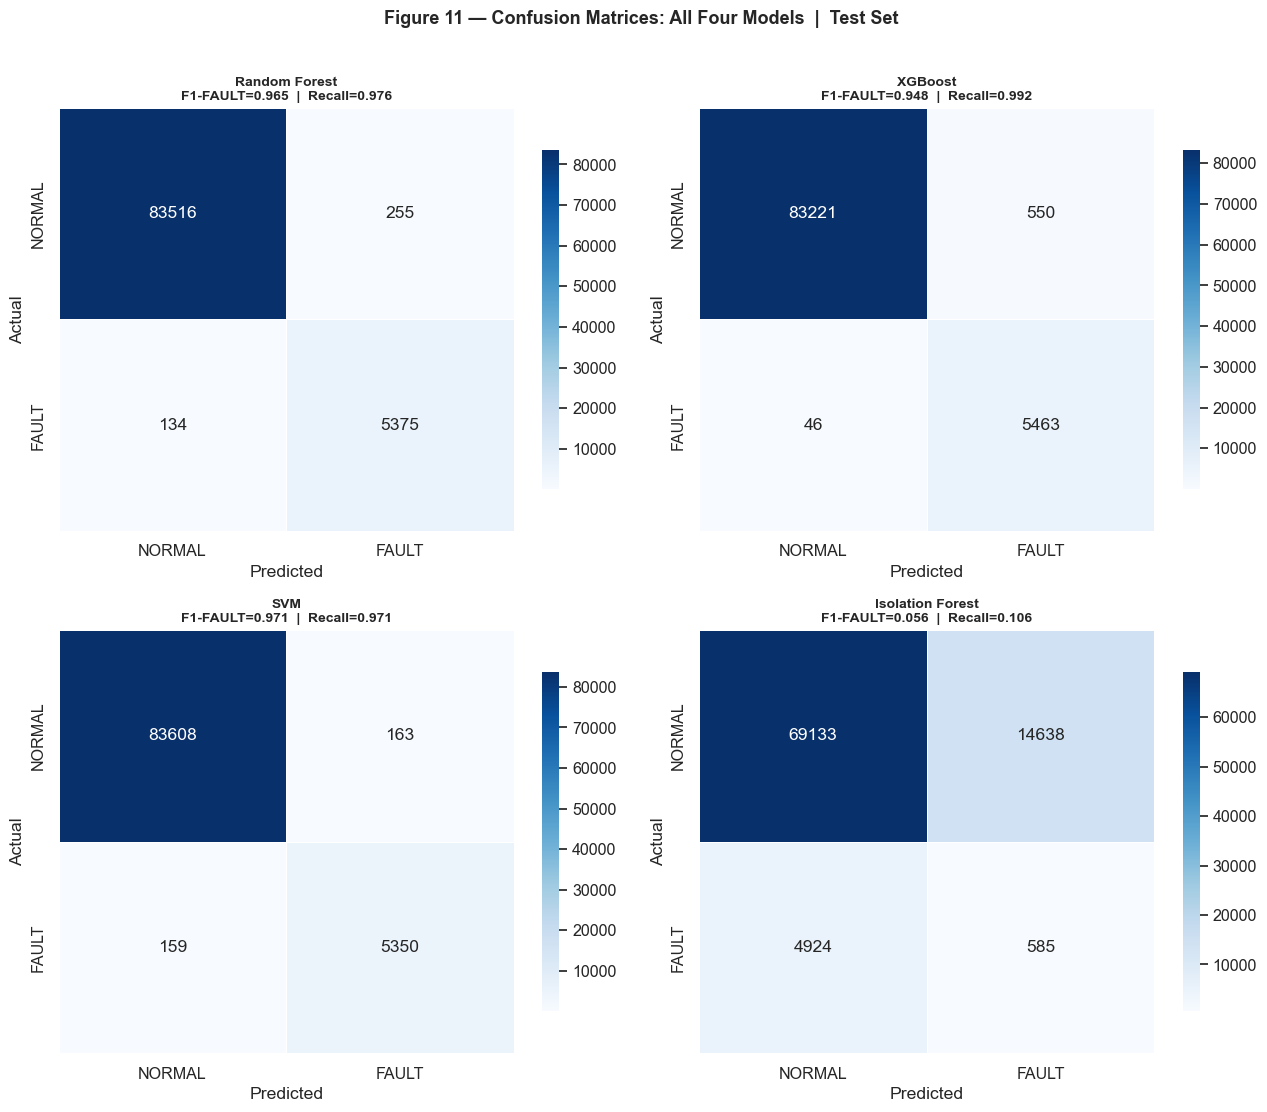

Figure 11 saved


In [8]:
model_names = ['Random Forest','XGBoost','SVM','Isolation Forest']
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle('Figure 11 — Confusion Matrices: All Four Models  |  Test Set',
             fontsize=13, fontweight='bold', y=1.01)
for ax, name in zip(axes.flat, model_names):
    cm = confusion_matrix(y_te, results[name]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['NORMAL','FAULT'], yticklabels=['NORMAL','FAULT'],
                linewidths=0.5, cbar_kws={'shrink':0.8})
    f1f = results[name]['rep']['FAULT']['f1-score']
    rec = results[name]['rep']['FAULT']['recall']
    ax.set_title(f'{name}\nF1-FAULT={f1f:.3f}  |  Recall={rec:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/figures/11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 11 saved')

## Cell 9 — Figure 12 & 13: ROC and PR Curves

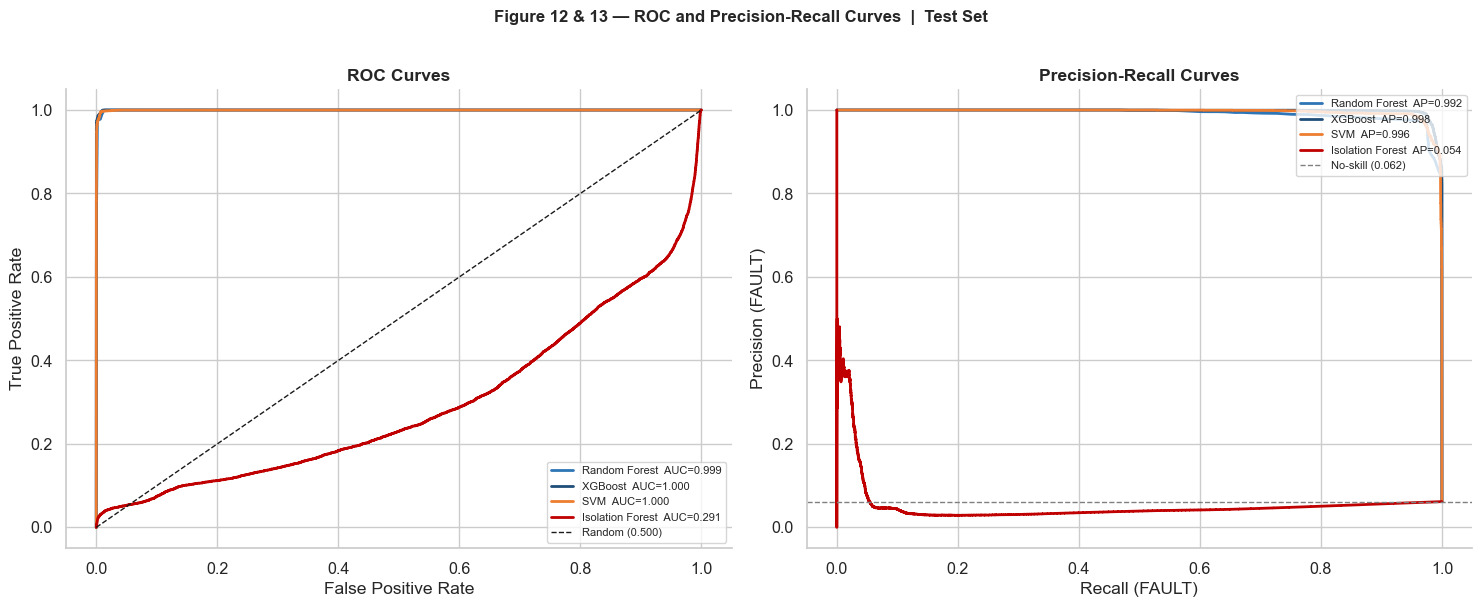

Figures 12-13 saved


In [9]:
colors = ['#2E75B6','#1F4E79','#ED7D31','#C00000']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 12 & 13 — ROC and Precision-Recall Curves  |  Test Set',
             fontsize=12, fontweight='bold', y=1.01)

# ROC
for (name, r), col in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_te, r['score'])
    axes[0].plot(fpr, tpr, color=col, lw=2,
                 label=f'{name}  AUC={r["roc"]:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random (0.500)')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8, loc='lower right')

# PR
baseline_pr = y_te.mean()
for (name, r), col in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_te, r['score'])
    axes[1].plot(rec, prec, color=col, lw=2,
                 label=f'{name}  AP={r["pr"]:.3f}')
axes[1].axhline(baseline_pr, color='grey', lw=1, linestyle='--',
                label=f'No-skill ({baseline_pr:.3f})')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].set_xlabel('Recall (FAULT)'); axes[1].set_ylabel('Precision (FAULT)')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('outputs/figures/12_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figures 12-13 saved')

## Cell 10 — Figure 14: Baseline Comparison Bar Chart

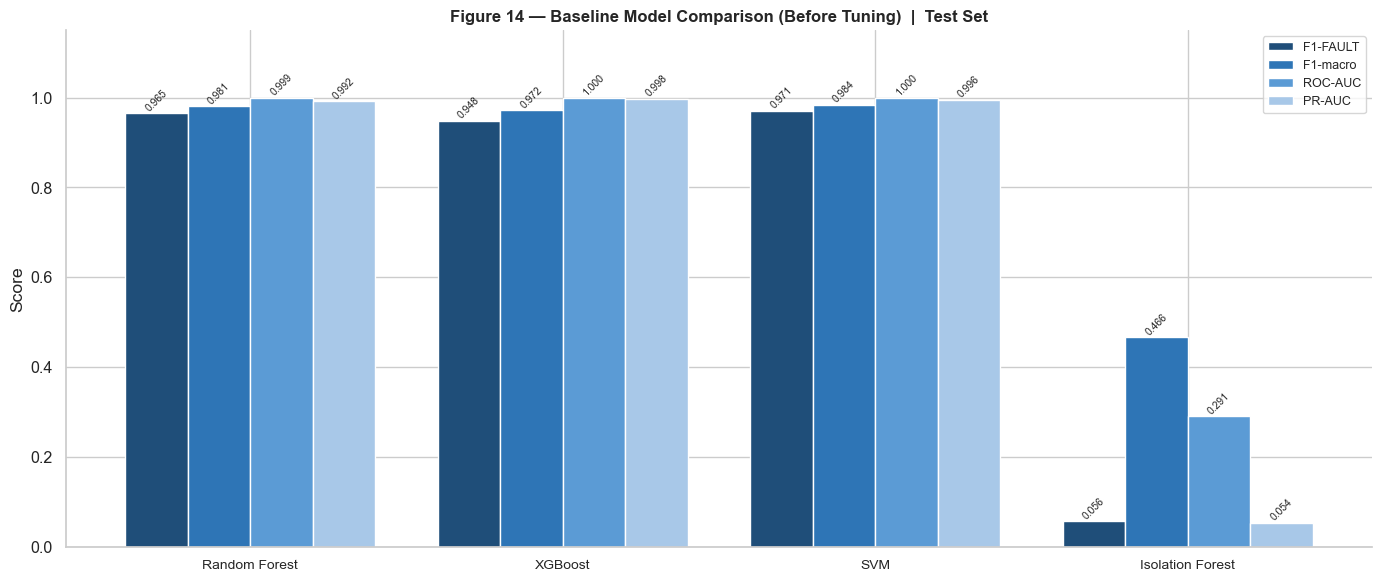

Figure 14 saved


In [10]:
metrics = ['F1-FAULT','F1-macro','ROC-AUC','PR-AUC']
vals = {m:[] for m in metrics}
for name in model_names:
    r = results[name]
    vals['F1-FAULT'].append(r['rep']['FAULT']['f1-score'])
    vals['F1-macro'].append(r['rep']['macro avg']['f1-score'])
    vals['ROC-AUC'].append(r['roc'])
    vals['PR-AUC'].append(r['pr'])

x = np.arange(len(model_names)); w = 0.2
pal = ['#1F4E79','#2E75B6','#5B9BD5','#A8C8E8']
fig, ax = plt.subplots(figsize=(14, 6))
for i,(metric,col) in enumerate(zip(metrics,pal)):
    bars = ax.bar(x+i*w-1.5*w, vals[metric], w, label=metric,
                  color=col, edgecolor='white')
    for bar,val in zip(bars,vals[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', fontsize=7.5, rotation=45)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=10)
ax.set_title('Figure 14 — Baseline Model Comparison (Before Tuning)  |  Test Set',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('outputs/figures/14_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 14 saved')

## Cell 11 — Results Summary & Save

In [11]:
out = {}
for name in model_names:
    r = results[name]
    out[name] = {
        'f1_fault':  round(r['rep']['FAULT']['f1-score'],4),
        'f1_macro':  round(r['rep']['macro avg']['f1-score'],4),
        'precision': round(r['rep']['FAULT']['precision'],4),
        'recall':    round(r['rep']['FAULT']['recall'],4),
        'roc_auc':   round(r['roc'],4),
        'pr_auc':    round(r['pr'],4)
    }
with open('outputs/baseline_results.json','w') as f:
    json.dump(out,f,indent=2)

print('='*62)
print(f'{"Model":<20} {"F1-FAULT":>9} {"F1-macro":>9} {"ROC-AUC":>9} {"PR-AUC":>9}')
print('-'*62)
for name in model_names:
    r = out[name]
    mark = ' ←best' if r['f1_fault']==max(v['f1_fault'] for v in out.values()) else ''
    print(f'{name:<20} {r["f1_fault"]:>9.4f} {r["f1_macro"]:>9.4f} {r["roc_auc"]:>9.4f} {r["pr_auc"]:>9.4f}{mark}')
print('='*62)
print('\nSaved: baseline_results.json  |  Trained models in outputs/trained_models/')
print('NEXT: Notebook 05 — Hyperparameter Tuning')

Model                 F1-FAULT  F1-macro   ROC-AUC    PR-AUC
--------------------------------------------------------------
Random Forest           0.9651    0.9814    0.9995    0.9917
XGBoost                 0.9483    0.9724    0.9999    0.9978
SVM                     0.9708    0.9844    0.9997    0.9955 ←best
Isolation Forest        0.0564    0.4662    0.2905    0.0536

Saved: baseline_results.json  |  Trained models in outputs/trained_models/
NEXT: Notebook 05 — Hyperparameter Tuning
